In [ ]:
!pip install pandas numpy scikit-learn xgboost shap lime matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2c36d547572d1441f5d7ba8d421d7d352e57b5c6266cf84950df1341d4ca2e2a
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Explainable AI
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier


In [ ]:
df = pd.read_csv("/content/diabetes.csv")

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}


In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"
])

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.707792   0.600000  0.500000  0.545455  0.812963
1        Decision Tree  0.675325   0.541667  0.481481  0.509804  0.630741
2        Random Forest  0.740260   0.634615  0.611111  0.622642  0.823333
3                  SVM  0.740260   0.652174  0.555556  0.600000  0.796389
4              XGBoost  0.759740   0.673469  0.611111  0.640777  0.808148


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:29:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"
])

# Round values for better readability
results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(3)

print("\nModel Comparison Table:\n")
print(results_df)


Model Comparison Table:

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     0.708      0.600   0.500     0.545    0.813
1        Decision Tree     0.675      0.542   0.481     0.510    0.631
2        Random Forest     0.740      0.635   0.611     0.623    0.823
3                  SVM     0.740      0.652   0.556     0.600    0.796
4              XGBoost     0.760      0.673   0.611     0.641    0.808


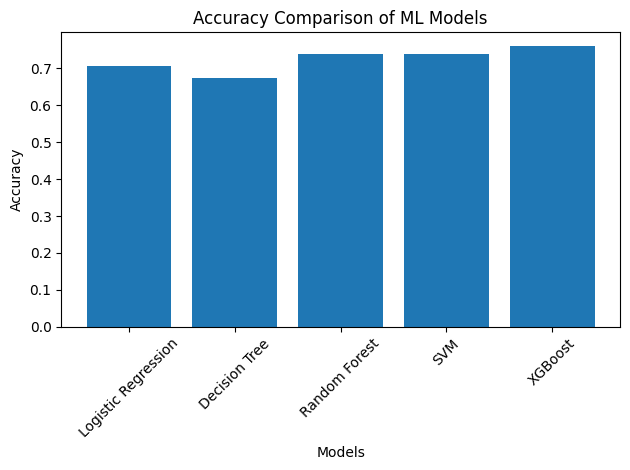

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Bar plot for accuracy
plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Accuracy Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

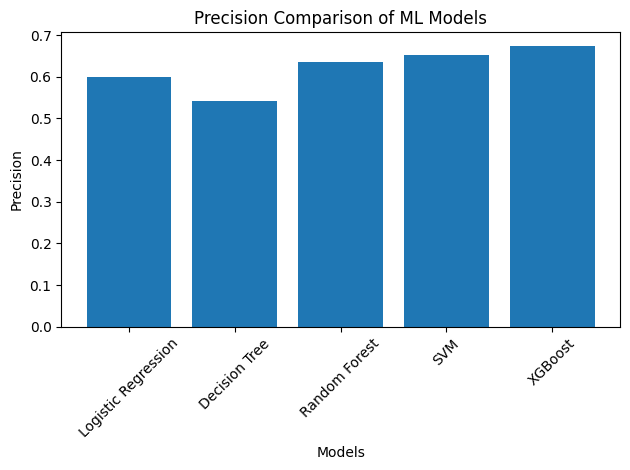

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Bar plot for Precision
plt.bar(results_df["Model"], results_df["Precision"])

plt.title("Precision Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("Precision")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

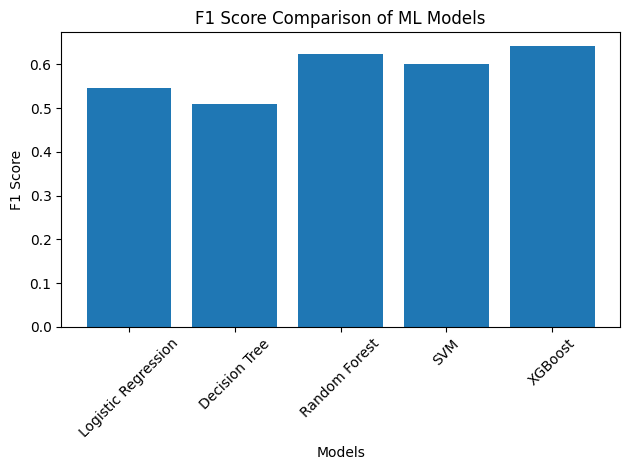

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Bar plot for F1 Score
plt.bar(results_df["Model"], results_df["F1 Score"])

plt.title("F1 Score Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

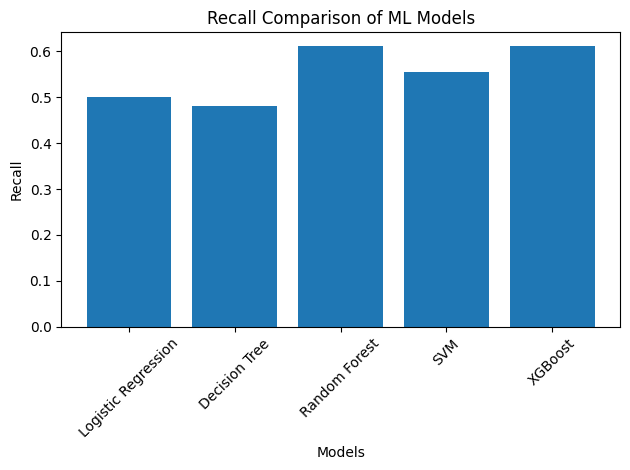

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Bar plot for Recall
plt.bar(results_df["Model"], results_df["Recall"])

plt.title("Recall Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("Recall")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

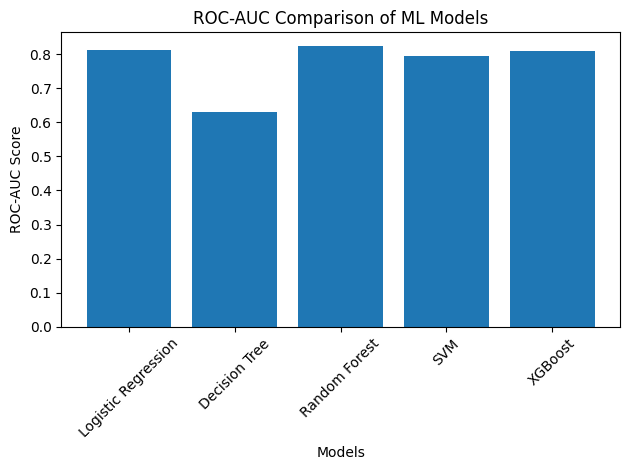

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Bar plot for ROC-AUC
plt.bar(results_df["Model"], results_df["ROC-AUC"])

plt.title("ROC-AUC Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

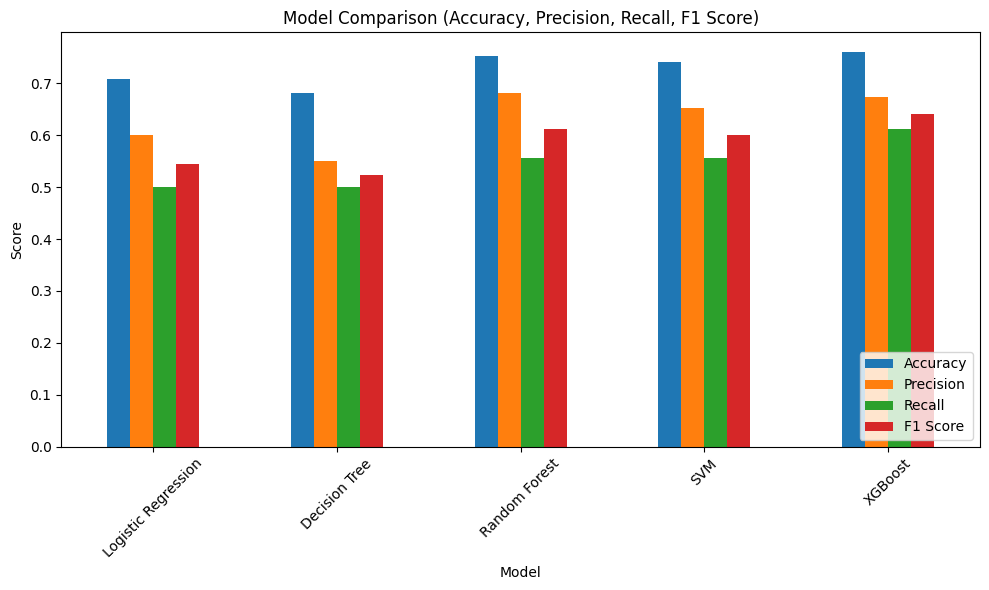

In [ ]:
# Set index as model names
df_plot = results_df.set_index("Model")

# Select only required metrics
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

# Plot
ax = df_plot[metrics].plot(kind='bar', figsize=(10,6))

plt.title("Model Comparison (Accuracy, Precision, Recall, F1 Score)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

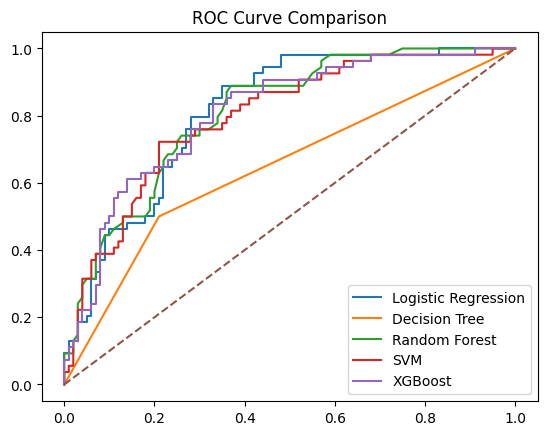

In [ ]:
plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

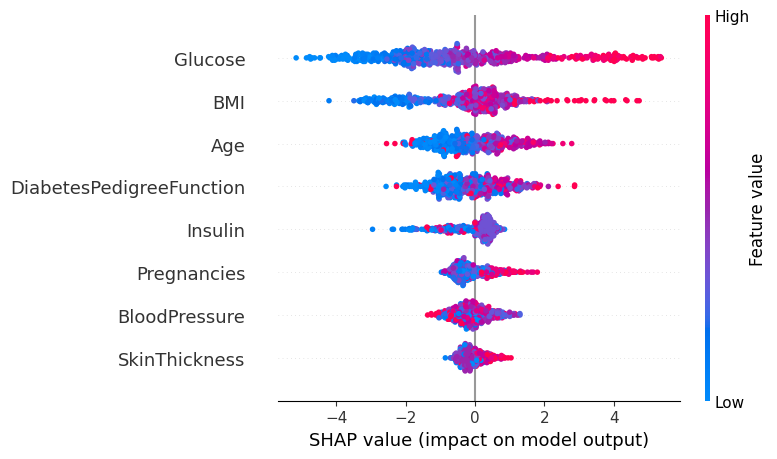

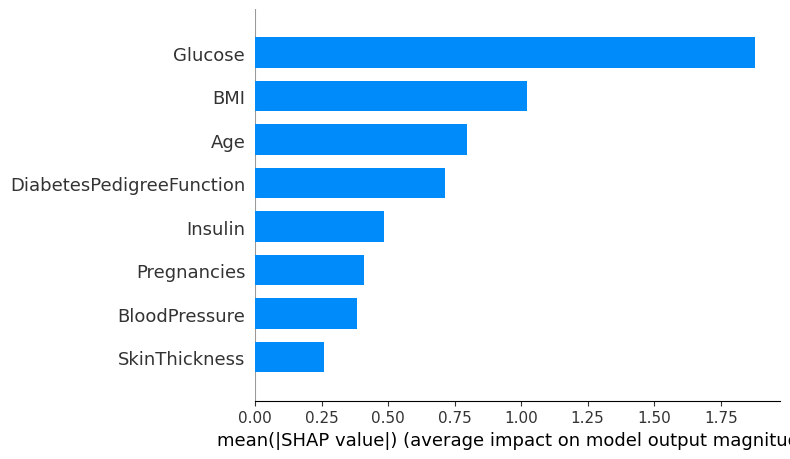

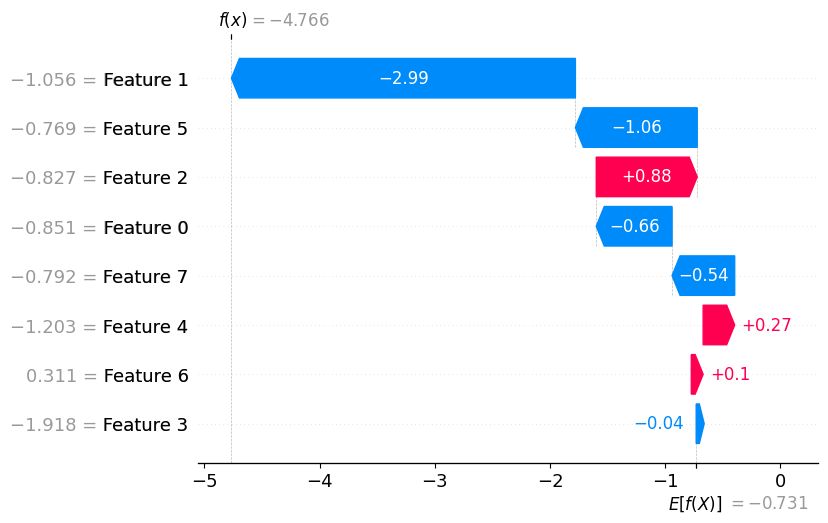

In [ ]:
xgb_model = models["XGBoost"]

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_train_scaled)

# Global Importance
shap.summary_plot(shap_values, X_train)

# Bar Plot
shap.summary_plot(shap_values, X_train, plot_type="bar")

# Local Explanation
shap.plots.waterfall(shap_values[0])

In [ ]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    mode="classification"
)

i = 5
exp = lime_explainer.explain_instance(
    X_test_scaled[i],
    xgb_model.predict_proba
)

exp.show_in_notebook()
exp.save_to_file("lime_output.html")

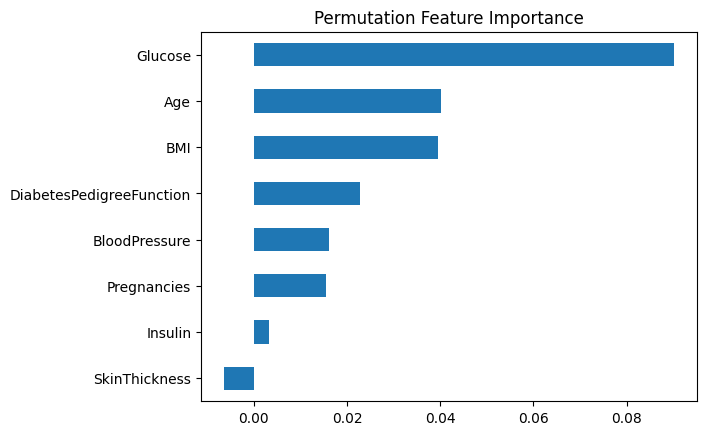

In [ ]:

perm = permutation_importance(
    xgb_model, X_test_scaled, y_test, n_repeats=10, random_state=42
)

importance = pd.Series(perm.importances_mean, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Permutation Feature Importance")
plt.show()


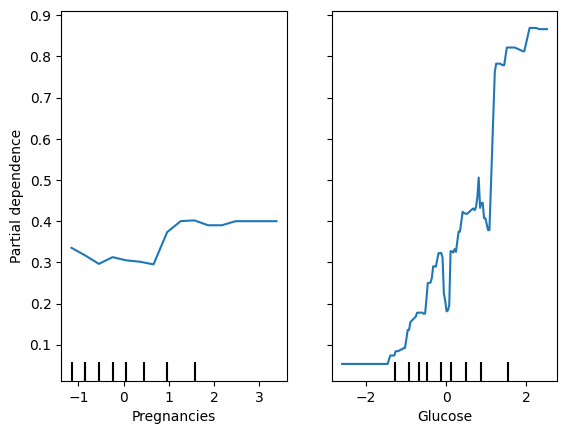

In [ ]:
features = [0, 1]  # Feature indices (e.g., Pregnancies, Glucose)

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_test_scaled,
    features=features,
    feature_names=X.columns
)

plt.show()

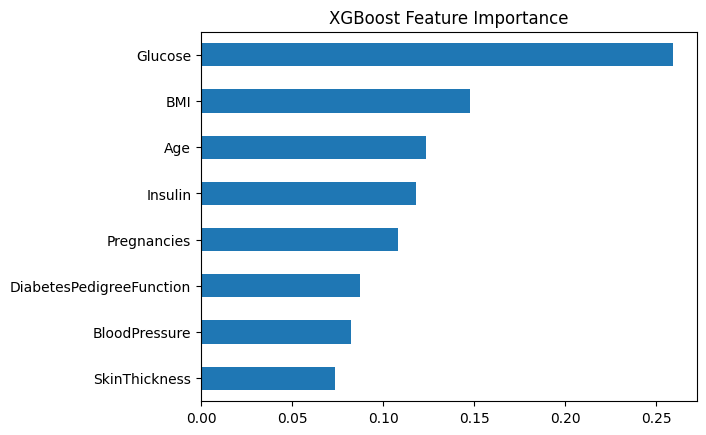

In [ ]:
importances = xgb_model.feature_importances_

pd.Series(importances, index=X.columns).sort_values().plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.show()